# Why we do?

중고차 시장 데이터를 기반으로 자동차 가격을 예측해보려 해요.

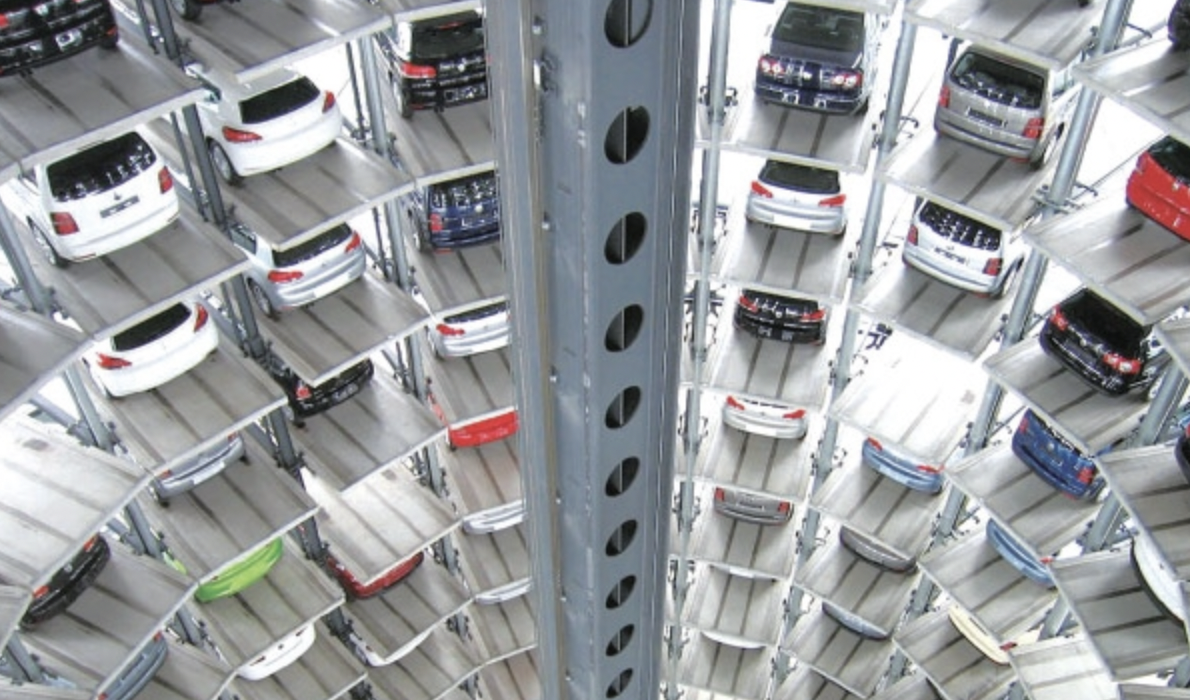

# Data

In [259]:
train = pd.read_csv("./drive-download-20220602T015750Z-001/train.csv")
test = pd.read_csv("./drive-download-20220602T015750Z-001/test.csv")
sample_submission = pd.read_csv("./drive-download-20220602T015750Z-001/sample_submission.csv")

train.drop(['id'],1,inplace=True)
test.drop(['id'],1,inplace=True)

In [5]:
train.head()

,title,odometer,location,isimported,engine,transmission,fuel,paint,year,target
0,Toyota RAV 4,18277,Lagos,Foreign Used,4-cylinder(I4),automatic,petrol,Red,2016,13665000
1,Toyota Land Cruiser,10,Lagos,New,4-cylinder(I4),automatic,petrol,Black,2019,33015000
2,Land Rover Range Rover Evoque,83091,Lagos,Foreign Used,6-cylinder(V6),automatic,petrol,Red,2012,9915000
3,Lexus ES 350,91524,Lagos,Foreign Used,4-cylinder(I4),automatic,petrol,Gray,2007,3815000
4,Toyota Venza,94177,Lagos,Foreign Used,6-cylinder(V6),automatic,petrol,Red,2010,7385000


* title : 제조사 모델명
* odometer : 주행 거리
* location : 판매처(나이지리아 도시)
* isimported : 현지 사용 여부
* engine : 엔진 종류
* transmission : 트랜스미션 종류
* fuel : 연료 종류
* paint : 페인트 색상
* year : 제조년도
* target : 자동차 가격

# Data Wrangling

In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         1015 non-null   object
 1   odometer      1015 non-null   int64 
 2   location      1015 non-null   object
 3   isimported    1015 non-null   object
 4   engine        1015 non-null   object
 5   transmission  1015 non-null   object
 6   fuel          1015 non-null   object
 7   paint         1015 non-null   object
 8   year          1015 non-null   int64 
 9   target        1015 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 79.4+ KB


In [15]:
train.isnull().sum()

title           0
odometer        0
location        0
isimported      0
engine          0
transmission    0
fuel            0
paint           0
year            0
target          0
dtype: int64

In [7]:
train.shape, test.shape

((1015, 10), (436, 9))

In [8]:
train.describe()

,odometer,year,target
count,1015.0000,1015.0000,1015.0000
mean,116842.1212,2008.3852,8243204.4502
std,105162.5458,35.5921,12395673.6040
min,0.0000,1217.0000,400000.0000
25%,55918.0000,2006.0000,2535000.0000
50%,94972.0000,2010.0000,4215000.0000
75%,153224.0000,2014.0000,8927500.0000
max,987322.0000,2020.0000,150015008.0000


**Obseravation**

* 주행거리(odometer)가 0인 데이터가 있습니다.
    * 사용하지 않은 차량인 듯 해요.
* 제조년도(year)가 1217년인 데이터가 있습니다.
* 자동차가격(target)에 매우 높은 값이 있습니다.

> 이상치를 처리해 줄 필요가 있습니다.

In [89]:
from IPython.core.display import HTML

def value_counts_all(df, columns):
    pd.set_option('display.max_rows',50)
    table_list=[]
    for col in columns:
        table_list.append(pd.DataFrame(df[col].value_counts()))
    return HTML(f"<table><tr> {''.join(['<td>'+table._repr_html_() + '</td>' for table in table_list])} </tr></table>")

value_counts_all(train,train.columns)

,title
Toyota Camry,129
Toyota Corolla,108
Toyota Highlander,50
Toyota Sienna,49
Toyota RAV 4,40
...,...
Scania P94 FLATBED,1
Mercedes-Benz GLA 250,1
Acura ZDX,1
Iveco TRUCK,1


**Observation**

* location 컬럼에 중복된 클래스가 존재해요.
* Paint 컬럼 내 클래스명을 처리해줘야 해요.

# EDA

In [213]:
cat_cols  = train.select_dtypes(include='object').columns.tolist()
num_cols  = train.select_dtypes(exclude='object').columns.tolist()

<Figure size 1152x864 with 0 Axes>

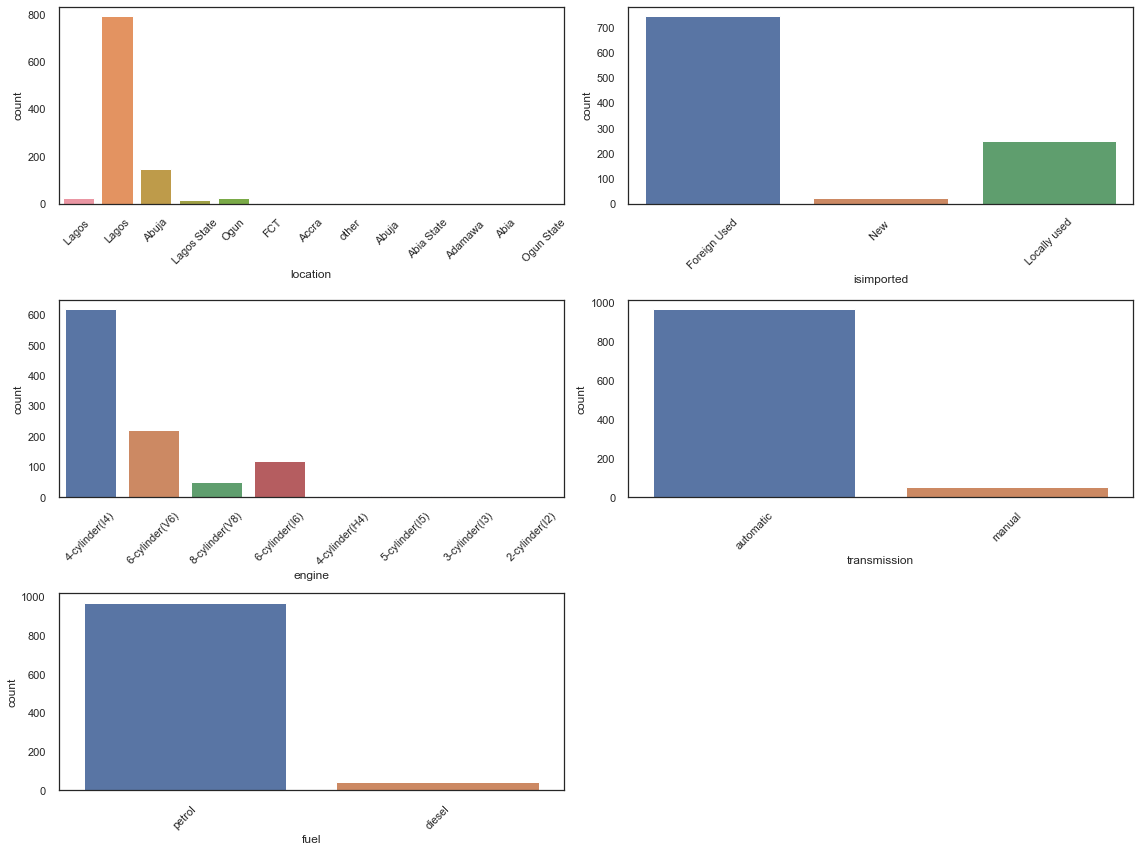

In [214]:
#categorical
sns.set(style='white')

i = 0
plt.figure(figsize=(16,12))
f,ax=plt.subplots(3,2,figsize=(16,12))
plt.delaxes(ax[2][1])
for col in ['location', 'isimported', 'engine', 'transmission', 'fuel']:
    i +=1
    plt.subplot(3,2,i)
    sns.countplot(x=train[col])
    plt.xticks(rotation=45)
    plt.tight_layout()

<Figure size 1080x216 with 0 Axes>

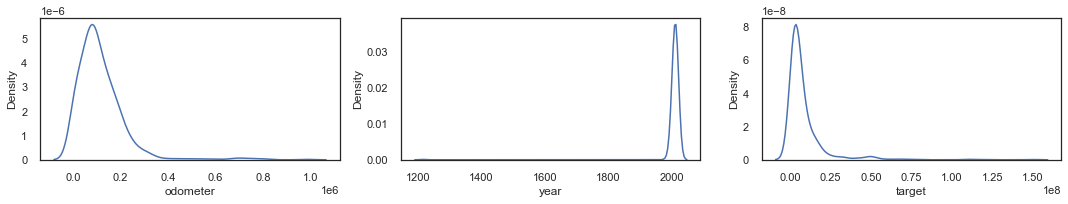

In [215]:
#categorical
sns.set(style='white')

i = 0
plt.figure(figsize=(15,3))
f,ax=plt.subplots(1,3,figsize=(15,3))
for col in num_cols:
    i +=1
    plt.subplot(1,3,i)
    sns.kdeplot(train[col])
    plt.tight_layout()

<AxesSubplot:>

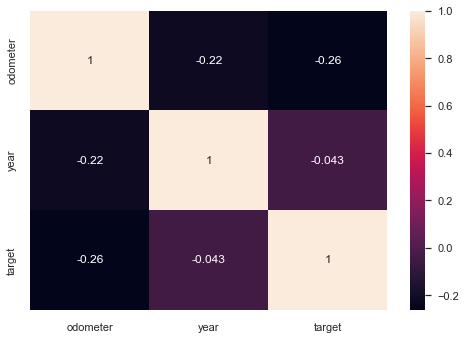

In [216]:
plt.figure()
sns.heatmap(train.corr(), annot=True)

**Observation** 

* 주행거리가 길다면 가격은 낮을 겁니다.

# Feature Engineering

In [260]:
train['manufacturer']=train['title'].str.split(' ',expand=True)[0]
test['manufacturer']=test['title'].str.split(' ',expand=True)[0]
train['manufacturer'].replace('Mercedes-Benz/52','Mercedes-Benz',inplace=True)

# Preprocessing

In [261]:
import re 

def clean_text(texts): 
    corpus = [] 
    for i in range(0, len(texts)): 
        review = re.sub(r'[@%\\*=()/~#&\+á?\xc3\xa1\-\|\.\:\;\!\-\,\_\~\$\'\"\n\]\[\>\<]', '',texts[i]) #@%*=()/+ 와 같은 문장부호 제거
        review = re.sub(r'\d+','',review)#숫자 제거
        review = review.lower() #소문자 변환
        review = re.sub(r'\s+', ' ', review) #extra space 제거
        review = re.sub(r'<[^>]+>','',review) #Html tags 제거
        review = re.sub(r'\s+', ' ', review) #spaces 제거
        review = re.sub(r"^\s+", '', review) #space from start 제거
        review = re.sub(r'\s+$', '', review) #space from the end 제거
        review = re.sub(r'_', ' ', review) #space from the end 제거
        review = re.sub(r'l', '', review)
        corpus.append(review) 
        
    return corpus

temp = clean_text(train['paint']) #메소드 적용
train['paint'] = temp

print('brand의 unique 카테고리 개수 : ', len(train['paint'].unique()))

train['paint'] = train['paint'] = train['paint'].apply(lambda x : 'blue' if x.find('blue') >= 0 else x)
train['paint'] = train['paint'] = train['paint'].apply(lambda x : 'red' if x.find('red') >= 0 else x)
train['paint'] = train['paint'] = train['paint'].apply(lambda x : 'green' if x.find('green') >= 0 else x)
train['paint'] = train['paint'] = train['paint'].apply(lambda x : 'white' if x.find('white') >= 0 else x)
train['paint'] = train['paint'] = train['paint'].apply(lambda x : 'grey' if x.find('grey') >= 0 else x)
train['paint'] = train['paint'] = train['paint'].apply(lambda x : 'grey' if x.find('gery') >= 0 else x)
train['paint'] = train['paint'] = train['paint'].apply(lambda x : 'grey' if x.find('gray') >= 0 else x)
train['paint'] = train['paint'] = train['paint'].apply(lambda x : 'ash' if x.find('ash') >= 0 else x)
train['paint'] = train['paint'] = train['paint'].apply(lambda x : 'brown' if x.find('brown') >= 0 else x)
train['paint'] = train['paint'] = train['paint'].apply(lambda x : 'silver' if x.find('silver') >= 0 else x)
train['paint'] = train['paint'] = train['paint'].apply(lambda x : 'silver' if x.find('sliver') >= 0 else x)
train['paint'] = train['paint'] = train['paint'].apply(lambda x : 'black' if x.find('black') >= 0 else x)
train['paint'] = train['paint'] = train['paint'].apply(lambda x : 'gold' if x.find('gold') >= 0 else x)
train['paint'] = train['paint'] = train['paint'].apply(lambda x : 'wine' if x.find('whine') >= 0 else x)

train['location']=clean_text(train['location'])
test['location'] = clean_text(test['location'])

brand의 unique 카테고리 개수 :  49


## 이상치

In [262]:
numeric_fts = ['odometer', 'year']
outlier_ind = []
for i in numeric_fts:
    Q1 = np.percentile(train[i],25)
    Q3 = np.percentile(train[i],75)
    IQR = Q3-Q1
    outlier_list = train[(train[i] < Q1 - IQR * 1.5) | (train[i] > Q3 + IQR * 1.5)].index
    outlier_ind.extend(outlier_list)
    
train = train.drop(outlier_ind, axis = 0).reset_index(drop = True)    

<Figure size 1152x864 with 0 Axes>

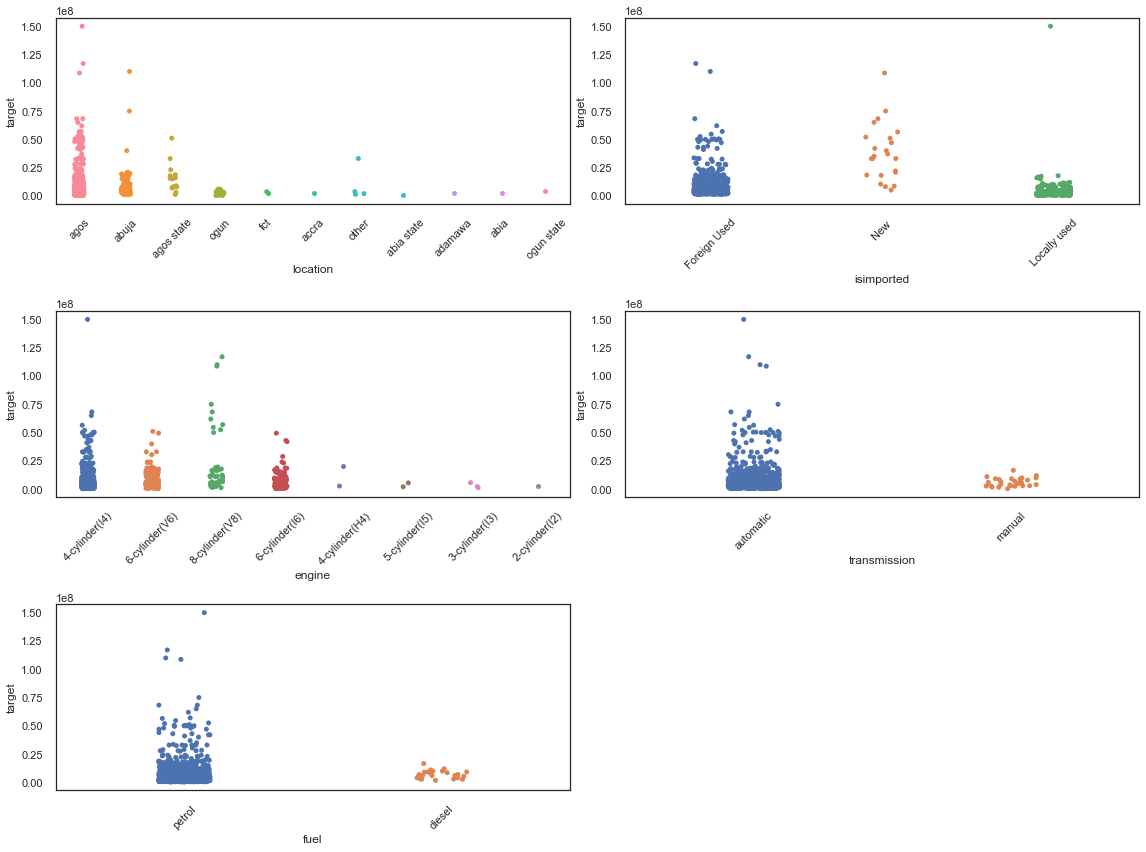

In [223]:
#categorical
sns.set(style='white')

i = 0
plt.figure(figsize=(16,12))
f,ax=plt.subplots(3,2,figsize=(16,12))
plt.delaxes(ax[2][1])
for col in ['location', 'isimported', 'engine', 'transmission', 'fuel']:
    i +=1
    plt.subplot(3,2,i)
    sns.stripplot(x=col, y ='target', data=train)
    plt.xticks(rotation=45)
    plt.tight_layout()

**Obseravation**

* location에 other클래스의 이상치를 제거합니다.
* isimported에 Locally used클래스의 이상치를 제거합니다.
* engine에 8-cylinder(V8)클래스의 이상치를 제거합니다.

In [263]:
train.drop(train[(train['location'] =='other') & (train['target'] > 0.25 * 1e8)].index, inplace=True)
train.drop(train[(train['isimported'] =='Locally used') & (train['target'] > 1.25 * 1e8)].index,inplace=True)
train.drop(train[(train['engine'] =='8-cylinder(V8)') & (train['target'] > 0.3 * 1e8)].index,inplace=True)

## YEAR

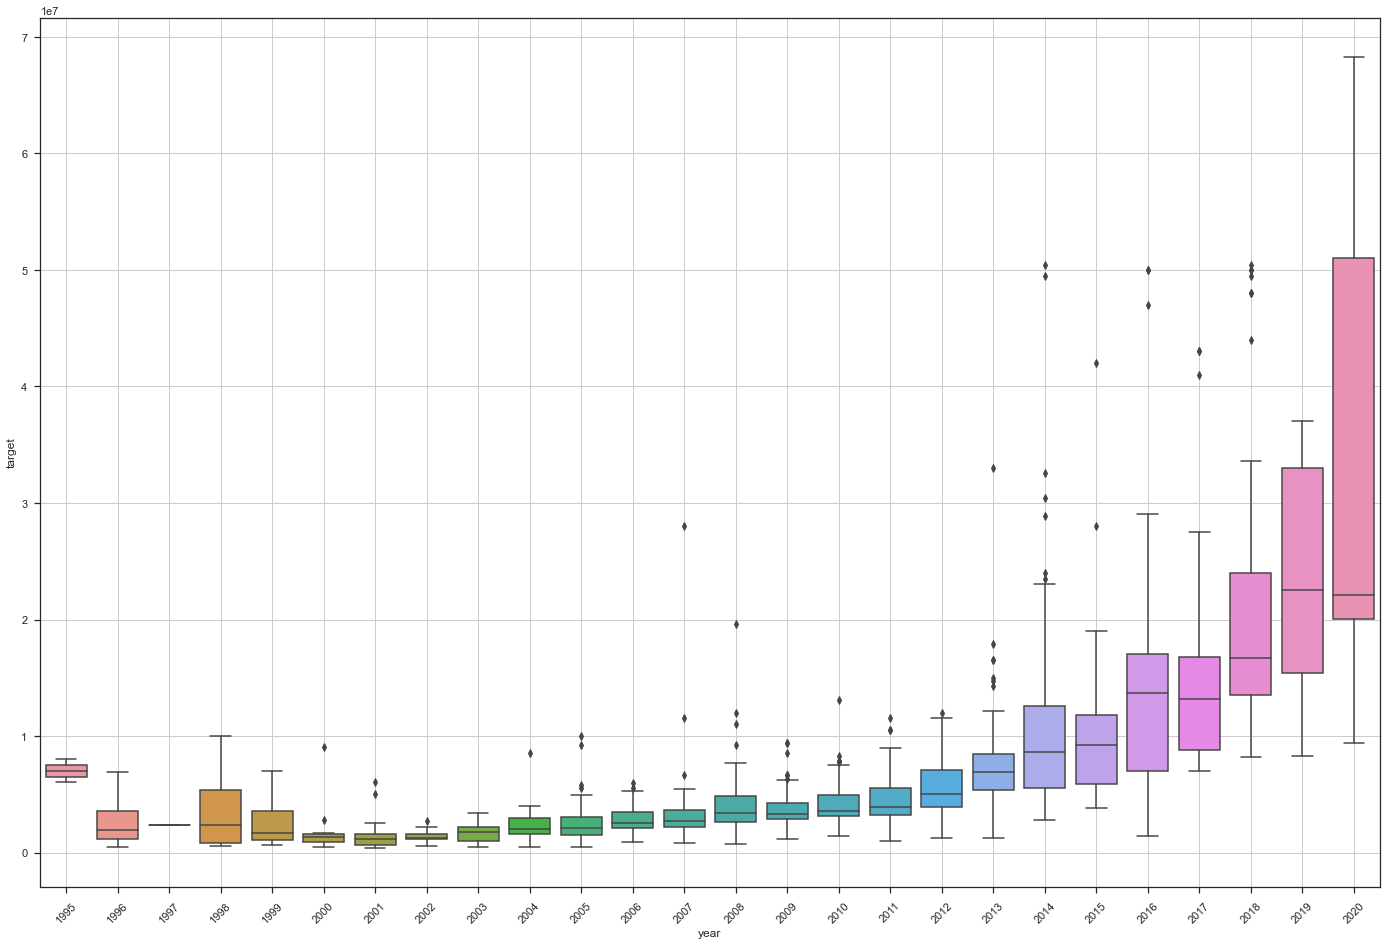

In [274]:
plt.figure(figsize=(24,16))
sns.set(style='ticks')
sns.boxplot(x='year', y='target',data=train)
plt.grid()
plt.xticks(rotation=45);

In [264]:
train.drop(train[train['year'] < 1995].index,inplace=True)

# Modeling

In [265]:
def make_label_map(dataframe):
    label_maps = {}
    for col in dataframe.columns:
        if dataframe[col].dtype=='object':
            label_map = {'unknown':0}
            for i, key in enumerate(dataframe[col].unique()):
                label_map[key] = i+1  #새로 등장하는 유니크 값들에 대해 1부터 1씩 증가시켜 키값을 부여해줍니다.
            label_maps[col] = label_map
    print(label_maps)
    return label_maps

# 각 범주형 변수에 인코딩 값을 부여하는 함수
def label_encoder(dataframe, label_map):
    for col in dataframe.columns:
        if dataframe[col].dtype=='object':
            dataframe[col] = dataframe[col].map(label_map[col])
            dataframe[col] = dataframe[col].fillna(label_map[col]['unknown']) #혹시 모를 결측값은 unknown의 값(0)으로 채워줍니다.
    return dataframe

le = make_label_map(train)
train = label_encoder(train, le)
train.head()

{'title': {'unknown': 0, 'Toyota RAV 4': 1, 'Toyota Land Cruiser': 2, 'Land Rover Range Rover Evoque': 3, 'Lexus ES 350': 4, 'Toyota Venza': 5, 'Toyota Corolla': 6, 'Land Rover Range Rover Sport': 7, 'Pontiac Vibe': 8, 'Toyota Tacoma': 9, 'Lexus RX 350': 10, 'Ford Escape': 11, 'Honda Civic': 12, 'Volvo XC90': 13, 'BMW 750': 14, 'Infiniti JX': 15, 'Honda Accord': 16, 'Mercedes-Benz ML 350': 17, 'Toyota Camry': 18, 'Hyundai Azera': 19, 'Lexus GX 460': 20, 'BMW 325': 21, 'Toyota Sienna': 22, 'Honda Fit': 23, 'Honda CR-V': 24, 'Hyundai Tucson': 25, 'Jaguar XJ8': 26, 'BMW X6': 27, 'Mercedes-Benz C 300': 28, 'Mitsubishi Galant': 29, 'Mercedes-Benz GL 450': 30, 'Lexus RX 300': 31, 'Toyota Highlander': 32, 'Mitsubishi CANTER PICK UP': 33, 'Nissan Titan': 34, 'Lexus IS 250': 35, 'Mercedes-Benz 200': 36, 'Toyota Sequoia': 37, 'Ford Explorer': 38, 'Hyundai ix35': 39, 'Lexus CT 200h': 40, 'Lexus LX 570': 41, 'Toyota Avensis': 42, 'Toyota 4-Runner': 43, 'Mercedes-Benz GLE 350': 44, 'Mercedes-Benz E

,title,odometer,location,isimported,engine,transmission,fuel,paint,year,target,manufacturer
0,1,18277,1,1,1,1,1,1,2016,13665000,1
1,2,10,1,2,1,1,1,2,2019,33015000,1
2,3,83091,1,1,2,1,1,1,2012,9915000,2
3,4,91524,1,1,1,1,1,3,2007,3815000,3
4,5,94177,1,1,2,1,1,1,2010,7385000,1


## CATBOOST

In [266]:
X = train.drop(['target'], axis = 1) #training 데이터에서 피쳐 추출
y = train.target #training 데이터에서 중고차 가격 추출

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.3, random_state=42)

from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

model = CatBoostRegressor(random_state=42,silent=True) # 모델 정의
model.fit(X_train,y_train) # 학습

def nmae(true, pred):

    mae = np.mean(np.abs(true-pred))
    score = mae / np.mean(np.abs(true))
    
    return score

mae_score= -1*(cross_val_score(estimator=model,X=X_train,y=y_train,cv=10,
               scoring='neg_mean_absolute_error'))
score = mae_score / np.mean(np.abs(y_train))

print(f'mean score : {score.mean()}, (+/-) {score.std()}')

mean score : 0.24708046862406938, (+/-) 0.03277625026267898


In [ ]:
test = label_encoder(test, le) #범주형 피쳐 라벨인코딩

In [280]:
from pycaret.regression import *

setup(data=train, target='target',fold_shuffle=True, session_id=123,silent=True)

,Description,Value
0,session_id,123
1,Target,target
2,Original Data,"(961, 11)"
3,Missing Values,0
4,Numeric Features,5
5,Categorical Features,5
6,Ordinal Features,0
7,High Cardinality Features,0
8,High Cardinality Method,None
9,Transformed Train Set,"(672, 26)"


AttributeError: 'Simple_Imputer' object has no attribute 'fill_value_categorical'

In [281]:
add_metric('nmae','NMAE',nmae,greater_is_better=False)

Name                                                       NMAE
Display Name                                               NMAE
Score Function                <function nmae at 0x7f836c7cd160>
Scorer               make_scorer(nmae, greater_is_better=False)
Target                                                     pred
Args                                                         {}
Greater is Better                                         False
Custom                                                     True
Name: nmae, dtype: object

In [283]:
blend_model = compare_models(n_select=4, sort='NMAE')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,NMAE,TT (Sec)
catboost,CatBoost Regressor,2002575.1801,18763065880198.1953,4060356.3370,0.7589,0.4432,0.3268,0.2740,0.1930
gbr,Gradient Boosting Regressor,2157866.1697,19878659590477.3711,4294742.1449,0.7166,0.4585,0.3600,0.2974,0.0190
rf,Random Forest Regressor,2265588.7209,22598579806725.9375,4528994.9868,0.6930,0.4056,0.3459,0.3103,0.0680
xgboost,Extreme Gradient Boosting,2276366.2500,24203874690662.3984,4534159.1500,0.6993,0.4603,0.3535,0.3123,0.3190
lightgbm,Light Gradient Boosting Machine,2383808.4912,22249955755879.1641,4548012.7196,0.6648,0.5148,0.4290,0.3289,0.5270
et,Extra Trees Regressor,2416547.6005,27169062704626.0469,4939033.7602,0.6231,0.4355,0.3833,0.3338,0.0590
dt,Decision Tree Regressor,2788957.2676,35238024199410.7891,5872323.4999,0.3969,0.5244,0.4206,0.3883,0.0040
ada,AdaBoost Regressor,3766163.7208,32785644740385.5820,5558166.3387,0.5033,0.7598,1.0330,0.5230,0.0140
ridge,Ridge Regression,3873467.0500,40440486585958.3984,6221871.1250,0.4195,0.8074,1.0013,0.5387,0.0040
lasso,Lasso Regression,3889131.9000,40726745422233.6016,6246855.2500,0.4126,0.8511,1.0055,0.5406,0.0070


In [284]:
blended_model = blend_models(blend_model,choose_better=True)

,MAE,MSE,RMSE,R2,RMSLE,MAPE,NMAE
0,2679913.1562,34026872475743.5586,5833255.7355,0.6766,0.4949,0.3104,0.3134
1,1751089.7655,9248106925117.5566,3041070.0296,0.6359,0.3381,0.3094,0.2887
2,2031588.6778,15095275602140.2168,3885263.9038,0.8181,0.2652,0.2270,0.2318
3,1745459.0321,8982794905937.8281,2997131.1126,0.8271,0.3400,0.2872,0.2367
4,1673719.9170,5928847053660.8486,2434922.3917,0.7893,0.3437,0.3156,0.2766
5,2233046.3065,18343954864257.8320,4282984.3409,0.7844,0.4265,0.4105,0.3147
6,2281469.9501,35102672946595.8281,5924750.8763,0.5351,0.3908,0.3041,0.3577
7,1313330.1423,5960820353610.9180,2441479.1323,0.8978,0.4427,0.3802,0.2184
8,2904155.0306,49341751299768.9062,7024368.3915,0.6318,0.4080,0.3314,0.3358
9,1978444.4433,14255153163533.9980,3775599.7091,0.8429,0.3716,0.3039,0.2480


In [285]:
final_model = finalize_model(blended_model)

In [286]:
test = label_encoder(test, le) #범주형 피쳐 라벨인코딩

In [287]:
predict_model(final_model, test)

,title,odometer,location,isimported,engine,transmission,fuel,paint,year,manufacturer,Label
0,28.0000,1234,2.0000,2,1.0000,1,1,0.0000,2017,10.0000,16653256.3038
1,16.0000,29938,2.0000,1,1.0000,1,1,0.0000,2013,6.0000,5560755.4256
2,0.0000,87501,1.0000,1,1.0000,1,1,0.0000,2012,10.0000,6713965.2962
3,22.0000,180894,1.0000,3,2.0000,1,1,0.0000,2001,1.0000,851272.7062
4,80.0000,104814,1.0000,1,1.0000,1,1,0.0000,2000,1.0000,2612799.5662
...,...,...,...,...,...,...,...,...,...,...,...
431,85.0000,78175,1.0000,1,2.0000,1,1,0.0000,2014,10.0000,9278737.6347
432,61.0000,129223,1.0000,1,2.0000,1,1,0.0000,2011,6.0000,4786970.7032
433,17.0000,100943,1.0000,1,1.0000,1,1,0.0000,2013,10.0000,8267482.1172
434,126.0000,81463,1.0000,1,1.0000,1,1,0.0000,2003,3.0000,2551009.0274


In [ ]:
sample_submission['target'] = prediction['Label']
sample_submission.to_csv("./drive-download-20220602T015750Z-001/submission.csv",index=False)

# Evaluate

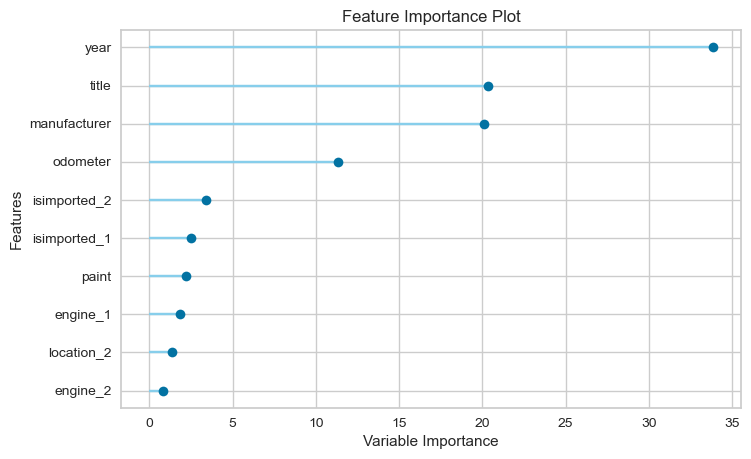

In [288]:
plot_model(final_model,plot='feature')

**Obseravation**

* year변수가 가장 중요했으며, title,manufacturer은 비슷한 중요도를 보이고 있습니다.
* paint와 odometer은 비교적 중요하지 않은 변수로 판단합니다.

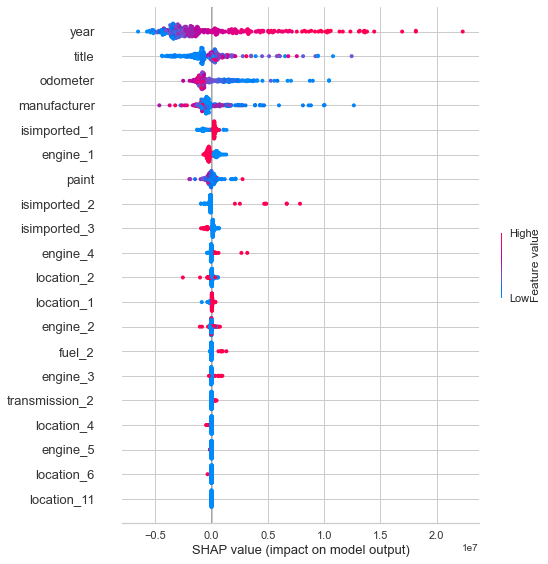

In [289]:
interpret_model(final_model,'summary')

**Obseravation**

* year값이 높으면 높을수록 높은 가격으로 책정합니다.
* odometer이 높은 경우, 즉 주행거리가 긴 경우에 낮은 가격으로 책정합니다.

In [290]:
interpret_model(final_model,'reason')

In [291]:
evaluate_model(final_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…